In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [64]:
df=pd.read_csv(r"C:\Users\anuna\OneDrive\Documents\Desktop\PROJECTS\Regression\student_habits_performance.csv")

In [65]:
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [66]:
df.shape

(1000, 16)

In [67]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [68]:
df = df.dropna()

In [69]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [70]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 909, dtype: bool

In [71]:
import warnings
warnings.filterwarnings("ignore")

In [72]:
df.describe(include="object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [73]:
categorical_cols = ("gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation")

In [74]:
for col in categorical_cols:
    print(f"value counts for {col}: \n {df[col].value_counts()}")


value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


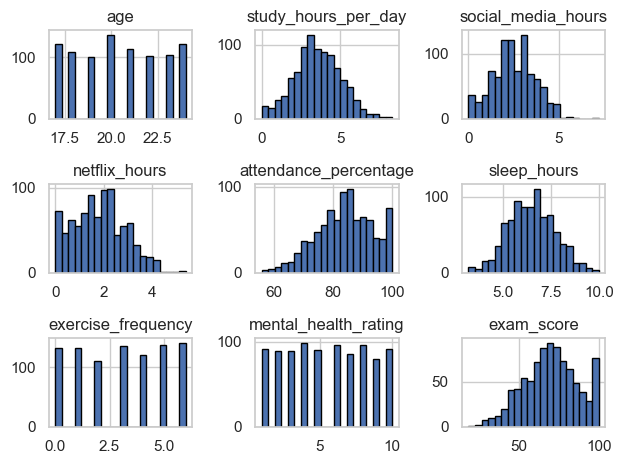

In [75]:
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

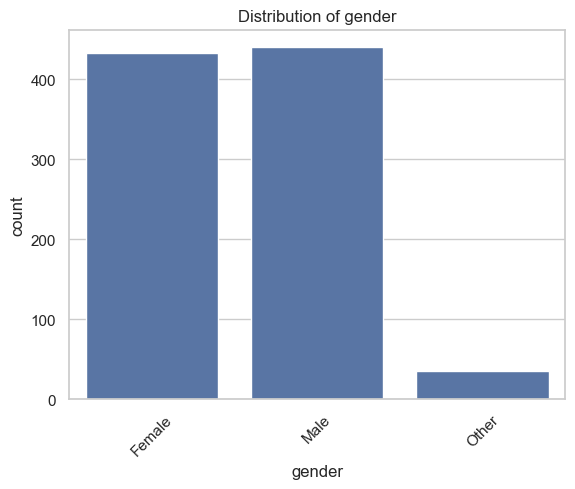

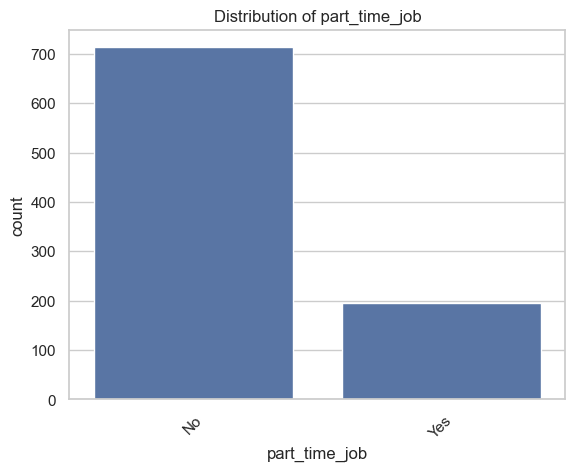

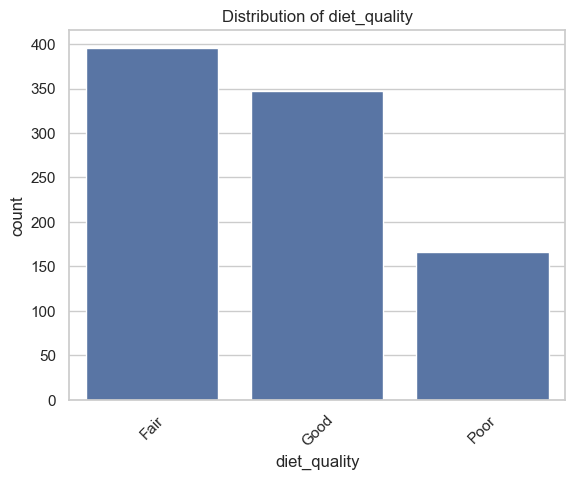

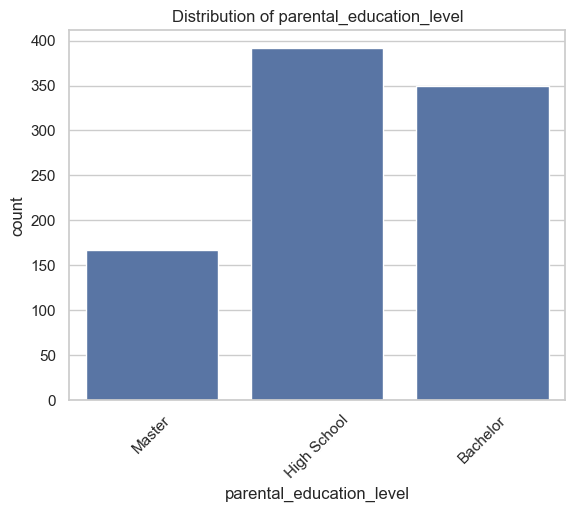

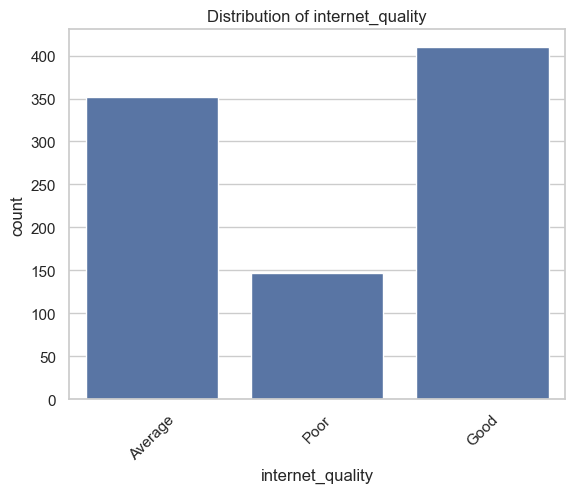

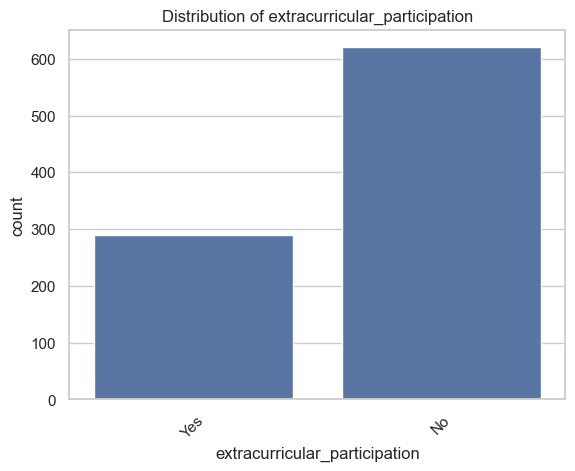

In [76]:
for col in categorical_cols:
    sns.countplot(data=df, x = col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()

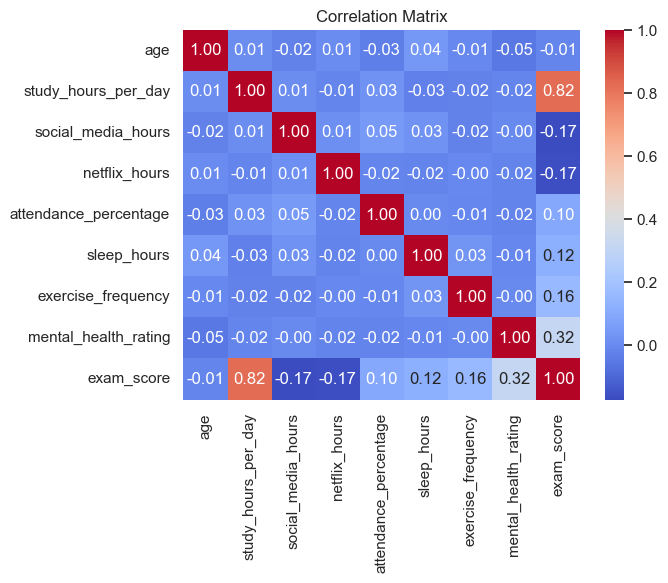

In [77]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [78]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [79]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],

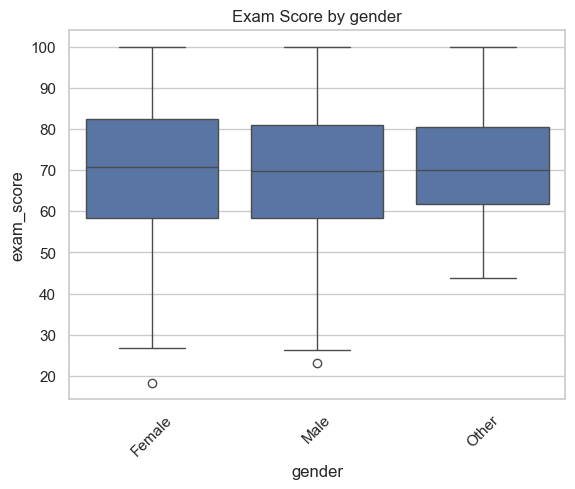

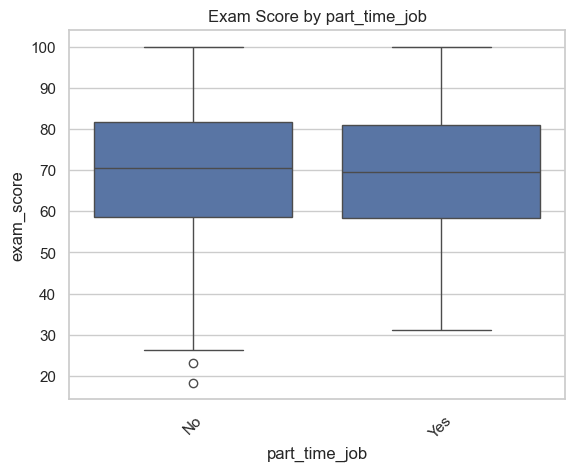

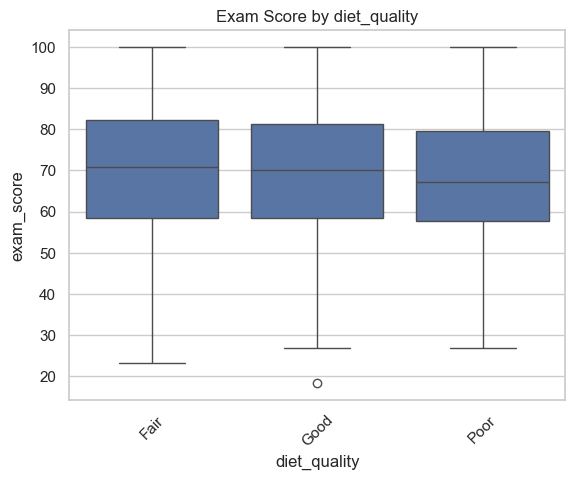

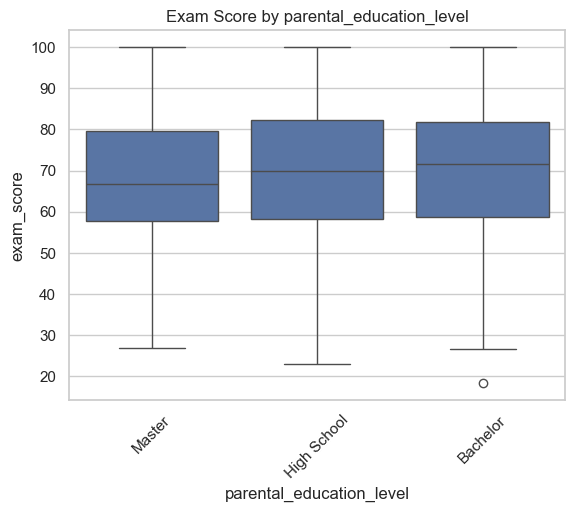

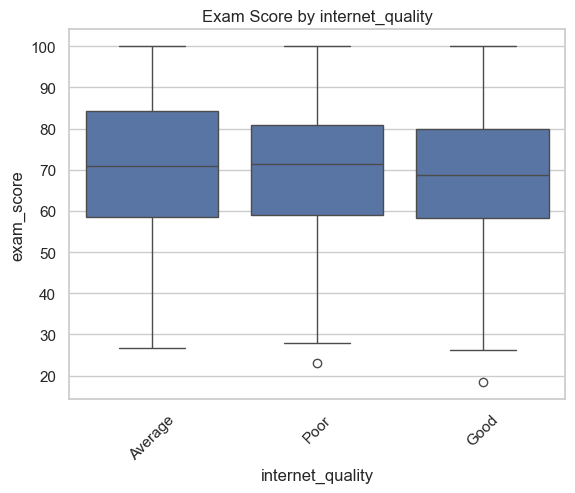

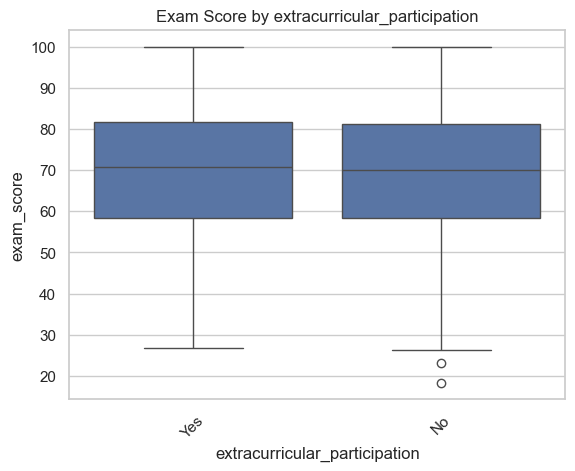

In [80]:
for col in categorical_cols:
    sns.boxplot(data = df, x=col, y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import  LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [82]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [83]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [84]:
features = ["study_hours_per_day",'attendance_percentage','mental_health_rating','sleep_hours','part_time_job']

In [85]:
target = "exam_score"

In [86]:
df_model = df[features + [target]].copy()

In [87]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [88]:
le = LabelEncoder()

In [89]:
df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

In [90]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [91]:
X = df_model[features]

In [92]:
y = df_model[target]

In [93]:
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.2)

In [94]:
len(y_test)

182

In [95]:
len(y_train)

727

In [96]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree" : {
        "model" : DecisionTreeRegressor(),
        "params" : {"max_depth": [3,5,10], "min_samples_split": [2,5]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [50,100], "max_depth": [5,10]}
    }
}

In [97]:
best_models = []

In [98]:
for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(config["model"],config["params"], cv=5, scoring="neg_mean_squared_error")
    grid.fit(x_train, y_train)
    
    y_pred = grid.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test,y_pred)

    best_models.append({
        "model":name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "r2":r2
    })

    

Training LinearRegression
Training DecisionTree
Training RandomForest


In [99]:
results_df= pd.DataFrame(best_models)

In [100]:
results_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},6.977087,0.798234
2,RandomForest,"{'max_depth': 10, 'n_estimators': 50}",7.489190,0.767529
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.579059,0.694945


In [101]:
import joblib

best_row = results_df.sort_values(by="rmse").iloc[0]

In [102]:
best_row

model          LinearRegression
best_params                  {}
rmse                   6.977087
r2                     0.798234
Name: 0, dtype: object

In [103]:
best_model_name = best_row["model"]

In [104]:
best_model_name

'LinearRegression'

In [105]:
best_model_config = models[best_model_name]

In [106]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [107]:
final_model = best_model_config["model"]

In [108]:
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [109]:
joblib.dump(final_model, "best_model.pkl")

['best_model.pkl']

In [110]:
joblib.load("best_model.pkl").predict(x_test)

array([ 74.5910171 ,  64.48227953,  54.1809859 ,  69.85675881,
        88.10129326,  71.53075848,  63.09414629, 100.91762465,
        76.89350005,  85.07977392,  85.77985132,  96.41397838,
        80.61992577,  47.52966995,  74.93620762,  91.91388896,
        73.63843002,  66.31366546,  70.31885498,  75.85209083,
        53.7393235 ,  64.33742269,  69.35389946,  57.8301418 ,
        62.79878985,  66.25211042,  63.44842876,  51.22222835,
        64.13092859, 115.32425793,  67.06989821,  77.22484193,
        72.41928765,  65.92873416,  93.5987542 ,  81.73266078,
        58.31327072,  94.26716699,  61.04952323,  77.42086604,
        76.45016176, 102.15537878,  60.37009385,  79.71753632,
        67.31865096,  52.60961208,  74.53698275,  63.72550851,
        63.60625277,  70.06256803, 102.67076152,  71.17382137,
        54.28921371,  50.57237348,  84.20309395,  65.9872718 ,
        66.18579405,  59.86149389,  64.87101299,  94.91445972,
        56.40314637,  65.04552732,  55.74098408,  63.74